In [12]:
import os
# 1. Suppress the memory leak warnings of KMeans on Windows in advance
os.environ["OMP_NUM_THREADS"] = "3"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [13]:
# ==========================================
# 1. Load the Dataset
# ==========================================
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print("--- First 5 Rows of Data ---")
print(df.head())
print("\n--- Basic Data Information ---")
print(df.info())

--- First 5 Rows of Data ---
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

--- Basic Data Information

In [14]:
# ==========================================
# 2. Data Cleaning
# ==========================================
# Fill in missing BMI values
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

# If the dataset contains the 'id' column, it needs to be removed during feature engineering, otherwise it will interfere with the model.
if 'id' in df.columns:
    df = df.drop('id', axis=1)

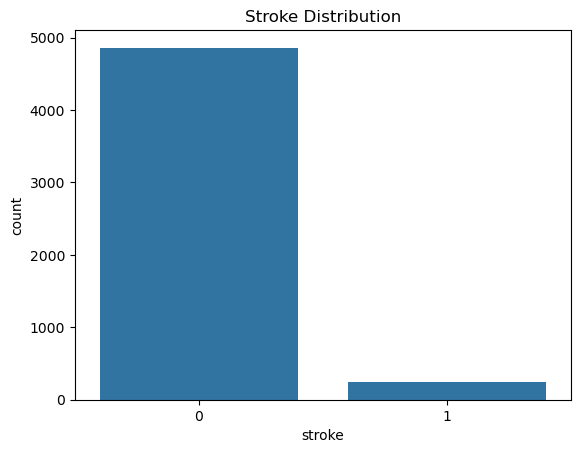

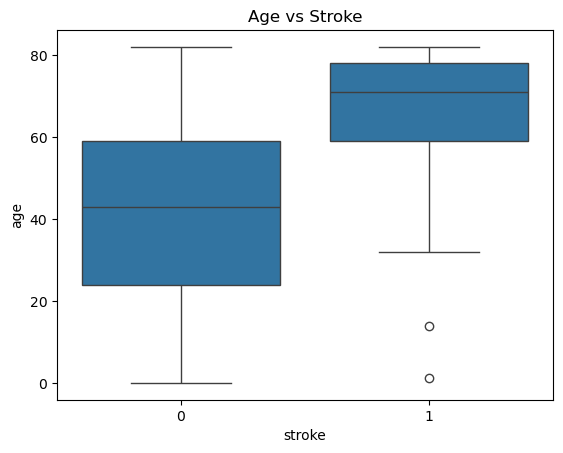

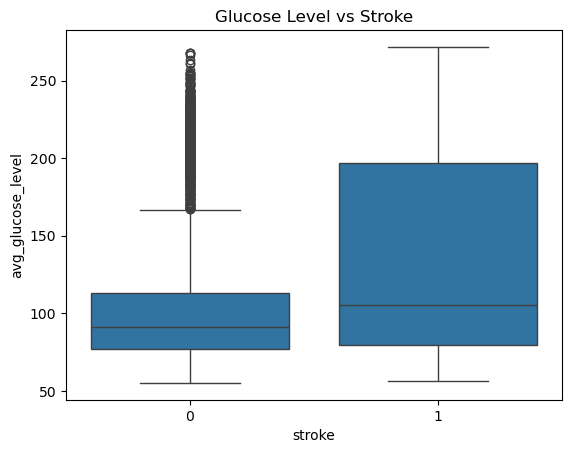

In [15]:
# ==========================================
# 3. Data Visualization
# ==========================================
plt.figure()
sns.countplot(x="stroke", data=df)
plt.title("Stroke Distribution")
plt.show()

plt.figure()
sns.boxplot(x="stroke", y="age", data=df)
plt.title("Age vs Stroke")
plt.show()

plt.figure()
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Glucose Level vs Stroke")
plt.show()

In [5]:
# ==========================================
# 4. Feature and Label Partitioning
# ==========================================
X = df.drop("stroke", axis=1)
y = df["stroke"]

categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
numerical_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi"]

In [17]:
# ==========================================
# 5. Build a Preprocessing Pipeline
# ==========================================
# Standardize numerical data and perform one-hot encoding on categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Dataset Splitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert Data (Enable the subsequent SMOTE and Random Forest to recognize text data)
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [18]:
# ==========================================
# 6. SMOTE Oversampling
# ==========================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

In [19]:
# ==========================================
# 7. Random Forest Classifier
# ==========================================
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train_encoded, y_train)

pred = rf.predict(X_test_encoded)

print("\n--- Classification Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))


--- Classification Model Evaluation ---
Accuracy: 0.7495107632093934

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.78      0.23        50

    accuracy                           0.75      1022
   macro avg       0.56      0.76      0.54      1022
weighted avg       0.94      0.75      0.82      1022



In [21]:
# ==========================================
# 8. KMeans Clustering
# ==========================================
# Clustering usually requires standardizing the full dataset.
full_pipeline = ColumnTransformer([('num', StandardScaler(), numerical_cols)])
X_scaled = full_pipeline.fit_transform(X) 

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["risk_cluster"] = clusters

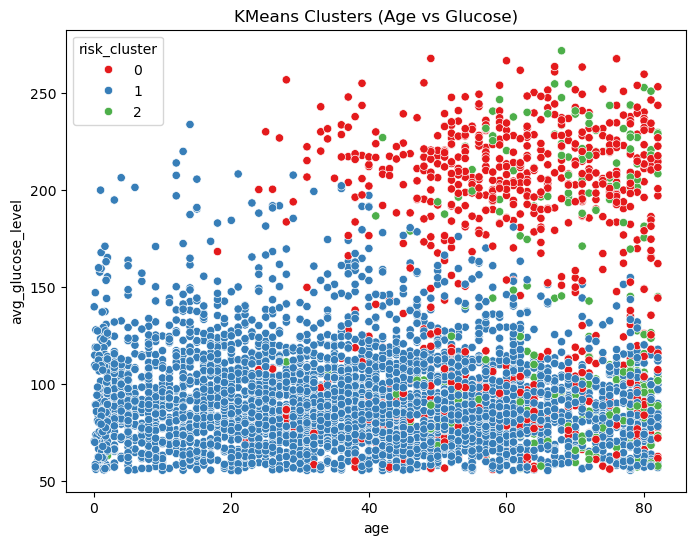

In [22]:
# ==========================================
# 9. Clustering Visualization
# ==========================================
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df["age"],
    y=df["avg_glucose_level"],
    hue=df["risk_cluster"],
    palette='Set1'
)
plt.title("KMeans Clusters (Age vs Glucose)")
plt.show()